In [9]:
import numpy as np
import pandas as pd
import scipy

import pingouin as pg

import seaborn as sns
from matplotlib import pyplot as plt

# fig2d

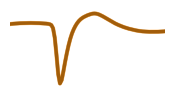

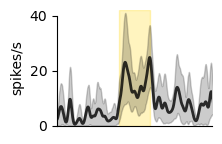

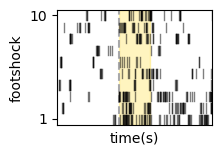

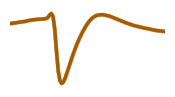

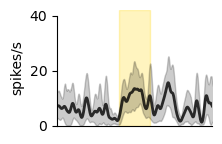

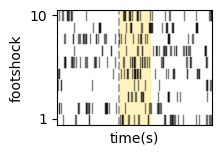

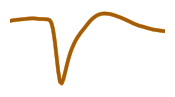

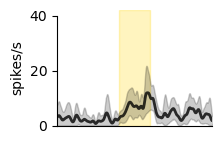

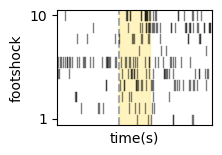

In [10]:
df_cl = pd.read_parquet('Fig2b.parquet')

for c in range( 3 ):

    tmp = df_cl.iloc[c]
    
    ################
    ################    
    fig, ax = plt.subplots(1,1, figsize = (2,1), sharey=False, sharex=True)
    ax.plot( np.arange( -2, 3, 5/len(tmp.mean_wf) ),
              tmp.mean_wf, 
             color='black', alpha=0.9, lw=2.5 )
    ax.plot( np.arange( -2, 3, 5/len(tmp.mean_wf_shocks) ),
              tmp.mean_wf, 
             color='darkorange', alpha=0.6, lw=3.0 )
    ax.set( xlim=(-1,2),
            xticks=[],
           yticks=[],
            xlabel= "",
          )

    sns.despine(offset=True, trim=True, left=True, right=True, bottom=True, top=True)

    ################
    ################
    fig, ax = plt.subplots(1,1, figsize = (2,1.5), sharey=False, sharex=True)
    ax.axvspan(0,1, color = 'gold', alpha=0.25)
    ax.fill_between(tmp.time, tmp.CIlow_rate, tmp.CIhigh_rate, color = 'black', alpha=0.2)
    ax.plot(tmp.time, tmp.mean_rate, color='black', lw=2.0, alpha=0.8)
    
    ax.set(
        ylabel='spikes/s', xlim=(-2, 3), ylim=(0,42),
        xlabel='', xticks=[],
    )
    sns.despine(offset=False, trim=True, left=False, right=True, bottom=False, top=True)

    ################
    ################
    fig, ax = plt.subplots(1,1, figsize = (2,1.5), sharey=False, sharex=True)
    ax.axvline( 0, ls='--', color= 'darkgrey' )
    ax.axvspan(0,1, color = 'gold', alpha=0.25, label='shocks')
    for t in range(10):
        for s in tmp[str(t)]:
            ax.axvline(s, ymin=0.95-t/10-0.04, ymax=0.95-t/10+0.04, 
                             color = 'black', alpha=0.5, lw=1.0) 
    
    ax.set(
        ylabel='footshock', xlim=(-2, 3), ylim=(0,42),
        xlabel='time(s)', xticks=[], yticks=[2.5,40],
    )
    ax.set_yticklabels([1,10])

# fig2c

/tmp/ipykernel_3500293/2444004269.py:18: RuntimeWarning: invalid value encountered in divide
  rates.append(np.nan_to_num(np.vstack([r / np.max(r) for r in tmp['rates_shocks']])))
/tmp/ipykernel_3500293/2444004269.py:18: RuntimeWarning: invalid value encountered in divide
  rates.append(np.nan_to_num(np.vstack([r / np.max(r) for r in tmp['rates_shocks']])))


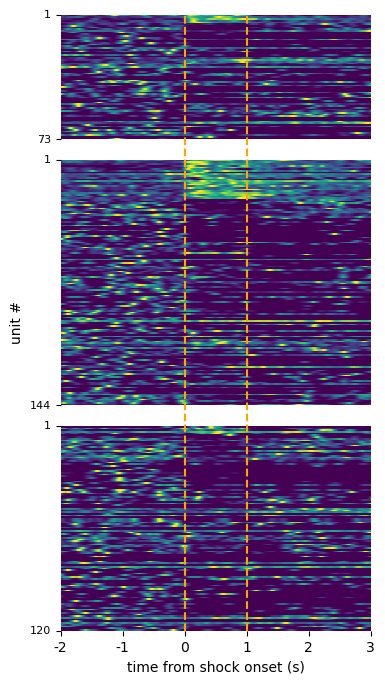

In [11]:
df_sum = pd.read_parquet('Fig2c.parquet')

gap   = 12   # blank rows between subregions
count = 0

rates    = []
units_N  = []
units_idx = []

for po in ['dorsal', 'intermediate', 'ventral']:
    tmp = (df_sum
           .set_index(['rat', 'cluster'])
           .query("pole == '{}'".format(po))
           .sort_values('shocks_response'))

    t = np.array(tmp['time'].iloc[0])

    rates.append(np.nan_to_num(np.vstack([r / np.max(r) for r in tmp['rates_shocks']])))
    rates.append(np.full((gap, len(t)), np.nan))
    units_N.append([1, len(tmp) ])
    units_idx.append([count, count + len(tmp)])
    count += len(tmp) + gap

fig, ax = plt.subplots(1, 1, figsize=(4, 8))
sns.heatmap(np.vstack(rates)[:-gap], cmap='viridis', cbar=None, ax=ax)

xlabels = [-2, -1, 0, 1, 2, 3]
xticks  = np.array([np.argmin(np.abs(t - ts)) for ts in xlabels])

ax.axvline(np.argmin(np.abs(t)),     color='orange', ls='--')  # shock onset
ax.axvline(np.argmin(np.abs(t - 1)), color='orange', ls='--')  # shock offset

ax.set(xlim=(xticks[0], xticks[-1]),
       ylabel='unit #', xlabel='time from shock onset (s)')
ax.set_xticks(xticks)
ax.set_xticklabels(xlabels, rotation=0)
ax.set_yticks(np.concatenate(units_idx))
ax.set_yticklabels(np.concatenate(units_N), rotation=0)
ax.tick_params(axis='y', labelsize=8)


# fig2d

/tmp/ipykernel_3500293/3862409244.py:21: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set(ylim=(0, 1),
/home/michon/.conda/envs/analysis/lib/python3.10/site-packages/scipy/stats/_axis_nan_policy.py:430: UserWarning: `kurtosistest` p-value may be inaccurate with fewer than 20 observations; only n=14 observations were given.
  return hypotest_fun_in(*args, **kwds)
/tmp/ipykernel_3500293/3862409244.py:36: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  normality = scipy.stats.normaltest(
/home/michon/.conda/envs/analysis/lib/python3.10/site-packages/scipy/stats/_axis_nan_policy.py:430: UserWarning: `kurtosistest` p-value may be inaccurate with fewer than 20 observations; only n=9 observations were given.
  return hypotest_fun_in(*args, **kwds)
/home/michon/.conda/envs/analysis/lib/python3.10/site-packages/

  Subregion: all
  AUC vs. chance (0.5):
               T  dof alternative     p_val          CI95   cohen_d     power    BF10
T_test  4.701875   13   two-sided  0.000414  [0.59, 0.73]  1.256629  0.991165  83.599

normality test: stat=1.4640379926985667 p=0.4809369991517827
  NON-RECALLER vs. RECALLER:
               T  dof alternative     p_val         CI95  cohen_d    power  BF10
T_test  0.683321   12   two-sided  0.507383  [-0.1, 0.2]  0.36525  0.09659  0.52

  Subregion: dorsal
  AUC vs. chance (0.5):
              T  dof alternative     p_val          CI95   cohen_d     power  BF10
T_test  1.22455    6   two-sided  0.266638  [0.41, 0.77]  0.462836  0.179367  0.62

normality test: stat=nan p=nan
  Subregion: intermediate
  AUC vs. chance (0.5):
               T  dof alternative    p_val          CI95  cohen_d  power     BF10
T_test  8.089951    8   two-sided  0.00004  [0.69, 0.85]  2.69665    1.0  607.431

normality test: stat=1.3163709832686736 p=0.5177900169279591
  Subregion: ve

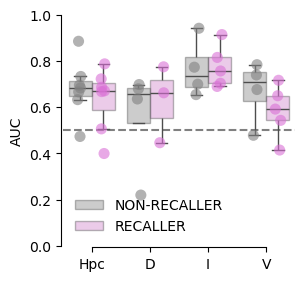

In [18]:
df_shock_behav = pd.read_parquet('Fig2d.parquet')

var = 'AUC'

fig, ax = plt.subplots(1, 1, figsize=(3, 3))
ax.axhline(0.5, color='grey', ls='--')

sns.boxplot(x='pole', hue='context_learning', y=var, data=df_shock_behav,
            order=['all', 'dorsal', 'intermediate', 'ventral'],
            hue_order=['not learned', 'learned'],
            palette=['grey', 'orchid'],
            boxprops=dict(alpha=0.4), fliersize=0.0, ax=ax)
sns.stripplot(x='pole', hue='context_learning', y=var, data=df_shock_behav,
              order=['all', 'dorsal', 'intermediate', 'ventral'],
              hue_order=['not learned', 'learned'],
              palette=['grey', 'orchid'],
              dodge=True, size=8, alpha=0.6, ax=ax)

handles, labels = ax.get_legend_handles_labels()
ax.legend(handles[:2], ['NON-RECALLER', 'RECALLER'], frameon=False)
ax.set(ylim=(0, 1),
       xticklabels=['Hpc', 'D', 'I', 'V'],
       xlabel='', ylabel='AUC')
sns.despine(offset=True, trim=True)


##Statistics
tmp = df_shock_behav.copy()

for area in np.unique(df_shock_behav.pole):
    results_chance = pg.ttest(
        x=tmp.query("pole == '{}'".format(area))['AUC'],
        y=0.5)

    # scipy.stats.shapiro(
    normality = scipy.stats.normaltest(
        np.array( tmp.query("pole == '{}'".format(area))['AUC'] ) )

    if area == 'all':
        results_group  = pg.ttest(
            tmp.query("pole == '{}' and context_learning == 'not learned'".format(area))['AUC'],
            tmp.query("pole == '{}' and context_learning == 'learned'".format(area))['AUC'],
            paired=False, correction=False)
    
    print("  Subregion: {}".format(area))
    print("  AUC vs. chance (0.5):")
    print(results_chance.to_string())
    print("")
    print("normality test: stat={} p={}".format(normality[0], normality[1]))
    if area == 'all':
        print("  NON-RECALLER vs. RECALLER:")
        print(results_group.to_string())
        print()

results_areas = pg.pairwise_tests(
    data=tmp.query("pole!='all'"), dv='AUC', between='pole', padjust='holm', 
    correction=False, 
    # parametric=False,
    effsize='cohen'
)

print(" areas:")
print(results_areas.to_string())
print()